## Frequentist vs Bayesian Inference

Statistical inference aims to learn about an unknown parameter $\mu$ from data.
The key difference between approaches is **where uncertainty comes from**:

* **Frequentist:** uncertainty comes from repeated sampling
* **Bayesian:** uncertainty comes from our knowledge about the parameter

*(See Casella & Berger, 2002; Gelman et al., 2013)*

---

### Comparison

| Aspect                | Frequentist View                   | Bayesian View                                       |
| --------------------- | ---------------------------------- | --------------------------------------------------- |
| Parameter ($\mu$)     | Fixed but unknown                  | Random variable                                     |
| Source of Uncertainty | Sampling variability               | Uncertainty about $\mu$                             |
| Role of Data          | Random sample                      | Observed data updates beliefs                       |
| Core Idea             | Repeated sampling (CLT)            | Prior → Posterior updating                          |
| Key Object            | Sampling distribution of $\bar{X}$ | Posterior distribution of $\mu$                     |
| Interval              | Confidence interval                | Credible interval                                   |
| Interpretation        | Long-run coverage                  | Probability about $\mu$                             |
| Typical Statement     | “95% of intervals contain $\mu$”   | “There is 95% probability $\mu$ is in the interval” |
| Hypothesis Testing    | Reject / fail to reject $H_0$      | Probability of hypotheses                           |
| Intuition             | “Machine over many samples”        | “Belief updated by data”                            |

---

### Intuition Bridge

* **Frequentist:**
  Before data → *“I know how the machine works”*
  After data → *“I pressed the machine once”*

* **Bayesian:**
  “I update my belief about $\mu$ after seeing the data”

---

### References

* Casella, G., & Berger, R. L. (2002). *Statistical Inference*.
* Hayashi, F. (2000). *Econometrics*.
* Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data*.
* Gelman, A., Carlin, J., Stern, H., Dunson, D., Vehtari, A., & Rubin, D. (2013). *Bayesian Data Analysis*.
* Efron, B., & Hastie, T. (2016). *Computer Age Statistical Inference*.


### Frequentist Simulation: Sampling and Confidence Intervals

In this simulation, we generate many samples from a population with true mean $\mu = 5$ and standard deviation $\sigma = 2$. For each sample:

* We compute the sample mean $\bar{X}$ and standard deviation $s$
* We construct a 95% confidence interval using
  $\bar{X} \pm t \cdot \frac{s}{\sqrt{n}}$
* We check whether the interval contains the true parameter $\mu$

By repeating this process many times, we approximate the **sampling distribution** of $\bar{X}$ and compute the **coverage rate** of the confidence interval.

This illustrates the frequentist idea:

* Different samples → different estimates and intervals
* The confidence interval is a **procedure** that works in the long run
* The coverage rate should be close to 95%

👉 This corresponds to:
“Before data → I know how the machine works”
“After data → I pressed the machine many times”


Average sample mean: 4.9924119815089805
Empirical SE: 0.28954238143575395
Coverage rate (~0.95 expected): 0.945


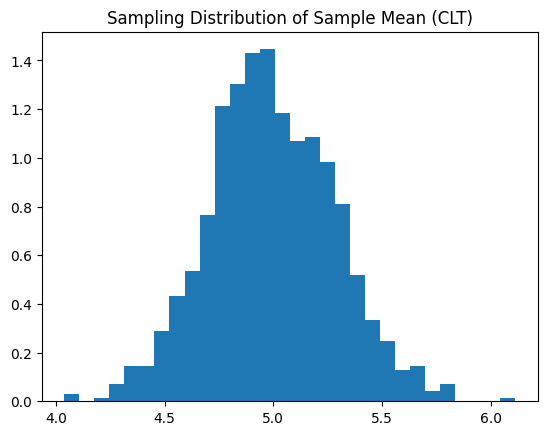

In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(0)

# True parameters
mu = 5
sigma = 2
n = 50
num_sim = 1000

means = []
cover_count = 0

for _ in range(num_sim):
    sample = np.random.normal(mu, sigma, n)
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)
    
    # t critical value
    t_crit = stats.t.ppf(0.975, df=n-1)
    
    # confidence interval
    ci_lower = x_bar - t_crit * s / np.sqrt(n)
    ci_upper = x_bar + t_crit * s / np.sqrt(n)
    
    means.append(x_bar)
    
    # check coverage
    if ci_lower <= mu <= ci_upper:
        cover_count += 1

# Results
print("Average sample mean:", np.mean(means))
print("Empirical SE:", np.std(means))
print("Coverage rate (~0.95 expected):", cover_count / num_sim)

# Plot CLT
plt.hist(means, bins=30, density=True)
plt.title("Sampling Distribution of Sample Mean (CLT)")
plt.show()

### Bayesian Simulation: Posterior and Credible Interval

In this simulation, we treat the parameter $\mu$ as uncertain and assign it a prior distribution. After observing data:

* We compute the sample mean $\bar{X}$
* We update our prior belief using the data to obtain a **posterior distribution** for $\mu$
* We construct a 95% credible interval from this posterior

Unlike the frequentist approach, we do not rely on repeated sampling. Instead, inference is based on **updating beliefs** using Bayes’ rule.

The resulting interval has a direct interpretation:

* It represents the range where $\mu$ is likely to lie given the data

👉 This reflects the Bayesian idea:

* Parameter is random
* Data updates beliefs
* Probability statements are about $\mu$, not a procedure


Posterior mean: 5.239204905383129
Credible interval: (np.float64(4.687037458960498), np.float64(5.7913723518057605))


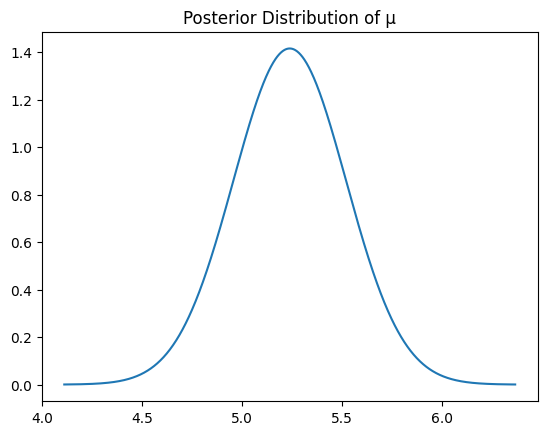

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# True parameters
mu_true = 5
sigma = 2
n = 50

# Prior: Normal(mu0, tau^2)
mu0 = 0
tau2 = 10

# Data
sample = np.random.normal(mu_true, sigma, n)
x_bar = np.mean(sample)

# Posterior calculations (known variance case)
posterior_var = 1 / (n/sigma**2 + 1/tau2)
posterior_mean = posterior_var * (n*x_bar/sigma**2 + mu0/tau2)
posterior_std = np.sqrt(posterior_var)

# Credible interval
ci_lower = posterior_mean - 1.96 * posterior_std
ci_upper = posterior_mean + 1.96 * posterior_std

print("Posterior mean:", posterior_mean)
print("Credible interval:", (ci_lower, ci_upper))

# Plot posterior
x = np.linspace(posterior_mean - 4*posterior_std,
                posterior_mean + 4*posterior_std, 1000)

posterior_pdf = (1 / (posterior_std * np.sqrt(2*np.pi))) * \
                np.exp(-0.5 * ((x - posterior_mean)/posterior_std)**2)

plt.plot(x, posterior_pdf)
plt.title("Posterior Distribution of μ")
plt.show()